Keys in NPZ: ['train_images', 'train_labels', 'val_images', 'val_labels', 'test_images', 'test_labels']


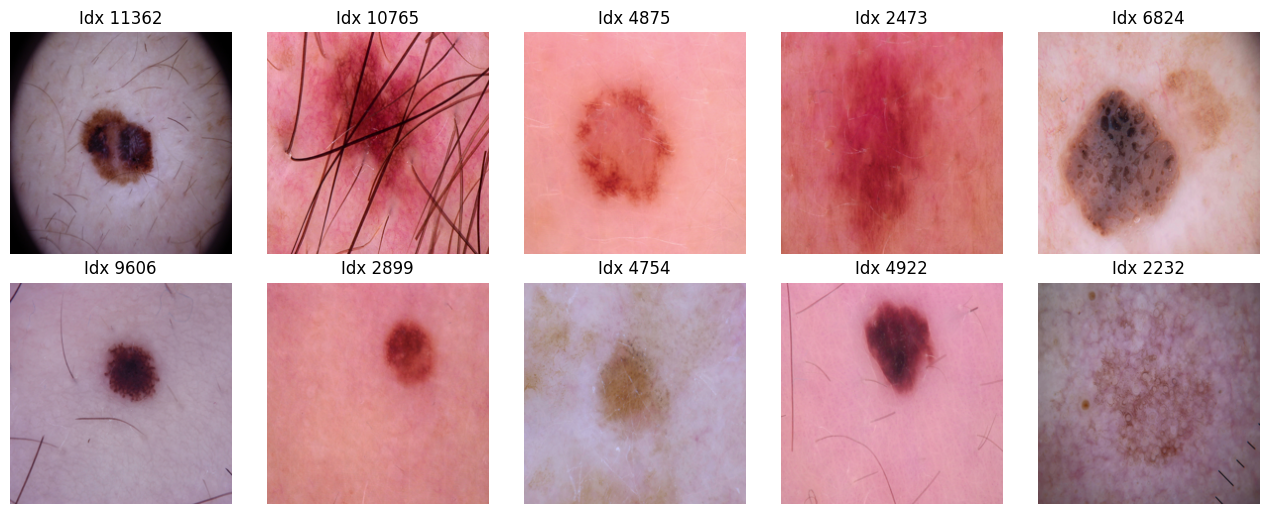

In [11]:
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

# Path to the .npz file
npz_path = Path("/mnt/data/psteinmetz/computer_vision_code/code/UQ_Toolbox/medMNIST/ISIC_2018/dermamnist_extended_224.npz")

if not npz_path.exists():
    raise FileNotFoundError(f"File not found: {npz_path}")

data = np.load(npz_path)
print("Keys in NPZ:", data.files)

# Collect candidate image arrays (heuristic)
image_arrays = []
for k in data.files:
    arr = data[k]
    if 'image' in k.lower() and arr.ndim >= 3:
        image_arrays.append(arr)

if not image_arrays:
    # Fallback: take first array with ndim >= 3
    for k in data.files:
        if data[k].ndim >= 3:
            image_arrays.append(data[k])
            print(f"Using fallback key: {k}")
            break

if not image_arrays:
    raise ValueError("No suitable image arrays found in the NPZ file.")

# Concatenate all image arrays along axis 0
images = np.concatenate(image_arrays, axis=0)
n_total = images.shape[0]
n_show = min(10, n_total)

rng = np.random.default_rng()
idx = rng.choice(n_total, size=n_show, replace=False)
sample = images[idx]

# Normalize for display if needed
if sample.dtype != np.uint8:
    max_val = sample.max()
    if max_val > 1:
        sample_disp = sample / max_val
    else:
        sample_disp = sample
else:
    sample_disp = sample / 255.0

cols = 5
rows = int(np.ceil(n_show / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.6, rows * 2.6))
axes = axes.flatten()

for ax, img, i in zip(axes, sample_disp, idx):
    if img.ndim == 2:
        ax.imshow(img, cmap='gray')
    elif img.ndim == 3 and img.shape[-1] == 1:
        ax.imshow(img[..., 0], cmap='gray')
    else:
        ax.imshow(img)
    ax.set_title(f"Idx {i}")
    ax.axis('off')

# Hide unused axes
for ax in axes[n_show:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [14]:
import pandas as pd

csv_path = npz_path.parent / "DermaMNIST-E.csv"
if not csv_path.exists():
    raise FileNotFoundError(f"File not found: {csv_path}")

derma_meta = pd.read_csv(csv_path)
display(derma_meta.head())

,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC,diag,diag_int,split,dataset
0,ISIC_0024306,0,1,0,0,0,0,0,nv,5,train,NaN
1,ISIC_0024307,0,1,0,0,0,0,0,nv,5,train,NaN
2,ISIC_0024308,0,1,0,0,0,0,0,nv,5,train,NaN
3,ISIC_0024309,0,1,0,0,0,0,0,nv,5,train,NaN
4,ISIC_0024310,1,0,0,0,0,0,0,mel,4,train,NaN


In [15]:
# Extract diag_int values for test split as a 1D numpy array
test_diag_int = derma_meta.loc[derma_meta['split'] == 'test', 'diag_int'].to_numpy()

print("test_diag_int shape:", test_diag_int.shape)
print("First 10 values:", test_diag_int[:10])

test_diag_int shape: (1511,)
First 10 values: [5 5 2 5 5 4 5 2 5 5]


In [16]:
# Compare NPZ test labels with metadata-derived test_diag_int

test_labels_npz = data['test_labels'].squeeze()  # (N,1) -> (N,)
print("NPZ test_labels shape:", test_labels_npz.shape, "dtype:", test_labels_npz.dtype)
print("Metadata test_diag_int shape:", test_diag_int.shape, "dtype:", test_diag_int.dtype)

if test_labels_npz.shape != test_diag_int.shape:
    print("Shape mismatch! Will compare up to min length.")
    n_cmp = min(len(test_labels_npz), len(test_diag_int))
else:
    n_cmp = len(test_labels_npz)

mismatch_idx = np.where(test_labels_npz[:n_cmp] != test_diag_int[:n_cmp])[0]
n_mismatch = mismatch_idx.size
print(f"Total compared: {n_cmp}")
print(f"Mismatches: {n_mismatch}")

if n_mismatch > 0:
    print("First 10 mismatch indices:", mismatch_idx[:10])
    print("Example (npz, meta):", list(zip(test_labels_npz[mismatch_idx[:10]], test_diag_int[mismatch_idx[:10]])))

# Class distribution comparison
binc_npz = np.bincount(test_labels_npz)
binc_meta = np.bincount(test_diag_int)
max_len = max(len(binc_npz), len(binc_meta))
binc_npz = np.pad(binc_npz, (0, max_len - len(binc_npz)))
binc_meta = np.pad(binc_meta, (0, max_len - len(binc_meta)))

print("\nClass | NPZ Count | Meta Count | Diff")
for cls, (c_npz, c_meta) in enumerate(zip(binc_npz, binc_meta)):
    diff = c_npz - c_meta
    print(f"{cls:5d} | {c_npz:9d} | {c_meta:9d} | {diff:4d}")

if n_mismatch == 0 and np.all(binc_npz == binc_meta):
    print("\nResult: Labels match exactly.")

NPZ test_labels shape: (1511,) dtype: uint8
Metadata test_diag_int shape: (1511,) dtype: int64
Total compared: 1511
Mismatches: 0

Class | NPZ Count | Meta Count | Diff
    0 |        43 |        43 |    0
    1 |        93 |        93 |    0
    2 |       217 |       217 |    0
    3 |        44 |        44 |    0
    4 |       171 |       171 |    0
    5 |       908 |       908 |    0
    6 |        35 |        35 |    0

Result: Labels match exactly.


In [ ]:
# Create a new NPZ including test_centers, saved under a new filename

# 1. Extract test acquisition centers (dataset column for test split)
test_centers_series = derma_meta.loc[derma_meta['split'] == 'test', 'dataset']
# Ensure we store as fixed-length Unicode (not object) so loading does not require allow_pickle=True
dataset_clean = test_centers_series.fillna('unknown').astype(str)
test_centers = dataset_clean.to_numpy(dtype=str)

# 2. Sanity check alignment with existing test_labels
if 'test_labels' in data.files and test_centers.shape[0] != data['test_labels'].shape[0]:
    raise ValueError(f"Length mismatch: test_centers={test_centers.shape[0]} vs test_labels={data['test_labels'].shape[0]}")

# 3. Collect existing arrays
existing = {k: data[k] for k in data.files}

# 4. Add new key
existing['test_centers'] = test_centers

# 5. Define new output path)
new_npz_path = npz_path.parent / "dermamnist_extended_224_wsitesources.npz"
np.savez_compressed(new_npz_path, **existing)

# 6. Verify
reloaded = np.load(new_npz_path)
print("New file saved at:", new_npz_path)
print("Contains test_centers:", 'test_centers' in reloaded.files)
print("test_centers shape:", reloaded['test_centers'].shape, "dtype:", reloaded['test_centers'].dtype)
print("First 5 centers:", reloaded['test_centers'][:5])
reloaded.close()


New file saved at: /mnt/data/psteinmetz/computer_vision_code/code/UQ_Toolbox/medMNIST/ISIC_2018/dermamnist_exteded_224_wsitesource.npz
Contains test_centers: True
test_centers shape: (1511,) dtype: <U13
First 5 centers: ['vidir_molemax' 'rosendahl' 'rosendahl' 'vienna_dias' 'vidir_molemax']


In [19]:
# Path to the .npz file
npz_path_wsitesources = Path("/mnt/data/psteinmetz/computer_vision_code/code/UQ_Toolbox/medMNIST/ISIC_2018/dermamnist_extended_224_wsitesources.npz")

if not npz_path_wsitesources.exists():
    raise FileNotFoundError(f"File not found: {npz_path_wsitesources}")

data_wsitesources = np.load(npz_path_wsitesources)
print("Keys in NPZ:", data_wsitesources.files)

Keys in NPZ: ['train_images', 'train_labels', 'val_images', 'val_labels', 'test_images', 'test_labels', 'test_centers']


In [21]:
data_wsitesources['test_centers'].shape

(1511,)